Pour ce tp de Toping modeling, on a décidé de comparer 3 modeles: le word2vec, DistilBert,LDA

Pour le choix de Word2vec: on a choisis ce modele pour ces 3 points principalement:

Facilité d'Utilisation : Word2Vec est simple à implémenter et dispose de nombreuses implémentations open source, le rendant accessible pour diverses tâches de NLP.

Amélioration des Performances NLP : Les embeddings de Word2Vec peuvent servir de pré-entraînement pour renforcer les performances dans des tâches spécifiques comme la classification de texte ou la traduction.

Économie de Ressources : Word2Vec offre un équilibre entre la qualité des représentations et l'utilisation efficace des ressources computationnelles, comparé à des modèles plus complexes.

Pour le choix de DistilBert:

DistilBERT est choisi pour le topic modeling en NLP car il offre une compréhension profonde et contextuelle du langage avec une efficacité accrue. Il est plus rapide et léger que BERT tout en conservant des performances élevées, ce qui le rend utile pour identifier des sujets complexes dans de grands ensembles de données textuelles.

Pour le choix de LDA: on l'a choisis car

Elle découvre automatiquement les topics dans un grand corpus de texte sans nécessiter d'étiquetage manuel.

Elle utilise une approche probabiliste pour modéliser chaque document comme un mélange de différents topics.

Les topics générés sont interprétables, ce qui aide à comprendre les thèmes dominants dans les données textuelles.

Elle est efficace et flexible, capable de gérer de grands volumes de données et permettant d'ajuster le nombre de topics et d'autres paramètres.

In [117]:
#librairies
import itertools
import os
import re
import secrets
import string
import numpy as np
import pandas as pd
import spacy
import json
import nltk
import scipy
from nltk.corpus import stopwords

from gensim import corpora, models
from gensim.models import CoherenceModel

from nltk.corpus import stopwords
import nltk
from collections import Counter
import matplotlib.pyplot as plt
from nltk.stem.wordnet import WordNetLemmatizer

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from nltk.tokenize import word_tokenize

from gensim.models.callbacks import CallbackAny2Vec
from gensim.models import Word2Vec, Phrases, KeyedVectors 
from gensim.models.phrases import Phraser
from gensim.utils import simple_preprocess
from nltk.corpus import wordnet

from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from tqdm import tqdm
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score
import pyLDAvis
import tomotopy as tp
from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification
import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from sklearn.decomposition import LatentDirichletAllocation
from transformers import DistilBertTokenizer, DistilBertModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import torch

from gensim.corpora.dictionary import Dictionary
from gensim.matutils import Sparse2Corpus

from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer


## Read data

In [20]:
def load_data(file_path):
    return pd.read_json(file_path, lines=True)

In [21]:
data = pd.read_json("News_Category_Dataset_v2.json", lines=True, dtype={"headline": str})

In [22]:
print("Nombre de sujets : ", len(data['category'].unique()))
print("Sujets : ", data['category'].unique())

Nombre de sujets :  41
Sujets :  ['CRIME' 'ENTERTAINMENT' 'WORLD NEWS' 'IMPACT' 'POLITICS' 'WEIRD NEWS'
 'BLACK VOICES' 'WOMEN' 'COMEDY' 'QUEER VOICES' 'SPORTS' 'BUSINESS'
 'TRAVEL' 'MEDIA' 'TECH' 'RELIGION' 'SCIENCE' 'LATINO VOICES' 'EDUCATION'
 'COLLEGE' 'PARENTS' 'ARTS & CULTURE' 'STYLE' 'GREEN' 'TASTE'
 'HEALTHY LIVING' 'THE WORLDPOST' 'GOOD NEWS' 'WORLDPOST' 'FIFTY' 'ARTS'
 'WELLNESS' 'PARENTING' 'HOME & LIVING' 'STYLE & BEAUTY' 'DIVORCE'
 'WEDDINGS' 'FOOD & DRINK' 'MONEY' 'ENVIRONMENT' 'CULTURE & ARTS']


## Exploring the dataset

compter mots uniques

In [23]:

def compter_mots_uniques(corpus):
    # Utiliser une expression régulière pour diviser le texte en mots
    mots = re.findall(r'\b\w+\b', corpus.lower())

    # Utiliser un ensemble pour obtenir les mots uniques
    mots_uniques = set(mots)

    # Afficher le nombre de mots uniques et la liste des mots
    print("Nombre de mots uniques:", len(mots_uniques))
    print("Liste des mots uniques:", mots_uniques)
    return len(mots_uniques)
mot_courant=[]
for i in range(10):
    mot_courant.append(compter_mots_uniques(data['short_description'][i]))
mot_courant

Nombre de mots uniques: 13
Liste des mots uniques: {'just', 'day', 'left', 'children', 'america', 'her', 'she', 'in', 'he', 'husband', 'their', 'killed', 'another'}
Nombre de mots uniques: 6
Liste des mots uniques: {'has', 'it', 'song', 'a', 'of', 'course'}
Nombre de mots uniques: 14
Liste des mots uniques: {'civil', 'anna', 'actor', 'tied', 'his', 'girlfriend', 'in', 'eberstein', 'longtime', 'a', 'and', 'the', 'ceremony', 'knot'}
Nombre de mots uniques: 15
Liste des mots uniques: {'trump', 'actor', 'for', 'kicking', 'gives', 'not', 'against', 'an', 'dems', 'ass', 'hard', 'the', 'enough', 'donald', 'fighting'}
Nombre de mots uniques: 12
Liste des mots uniques: {'using', 'bags', 'is', 'therapeutic', 'cathartic', 'said', 'moment', 'actress', 'a', 'the', 'really', 'dietland'}
Nombre de mots uniques: 21
Liste des mots uniques: {'or', 'humor', 'said', 'equate', 'to', 'is', 'it', 'not', 'incidents', 'sexual', 'in', 'assault', 'he', 'of', 'a', 'misplaced', 'statement', 'horrific', 'with', 'ri

[13, 6, 14, 15, 12, 21, 5, 9, 14, 9]

Pour notre probleme de toping modeling, on a décidé de partir sur les colonnes "headline" et "short_description"

In [24]:
data['processed_text'] = data['headline'] + ' ' + data['short_description']

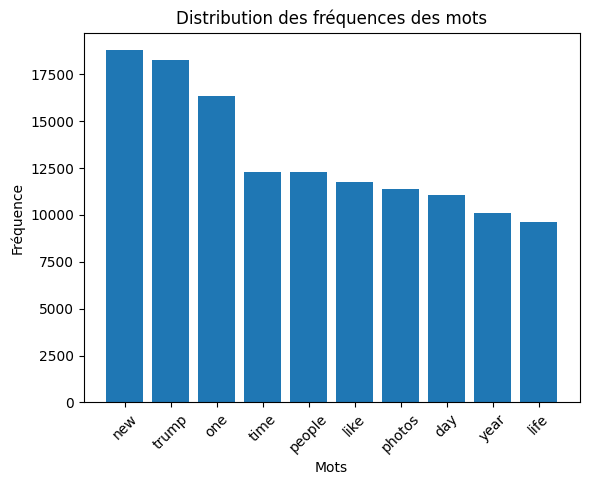

In [25]:

#nltk.download('stopwords')
#fréquence de chaque mot
def generer_histogramme_frequences(corpus, nombre_mots_affiches=10):
    mots = re.findall(r'\b\w+\b', ' '.join(corpus).lower())
    mots_filtrés = [mot for mot in mots if mot not in stopwords.words('english')]
    compteur_mots = Counter(mots_filtrés)
    mots_frequents = compteur_mots.most_common(nombre_mots_affiches)

    labels, valeurs = zip(*mots_frequents)

    plt.bar(labels, valeurs)
    plt.xlabel('Mots')
    plt.ylabel('Fréquence')
    plt.title('Distribution des fréquences des mots')
    plt.xticks(rotation=45)
    plt.show()



generer_histogramme_frequences(data['processed_text'], nombre_mots_affiches=10)

Nous comptons l'occurences des mots dans notre corpus. Pour cela, nous utilisons une fonction dummy pour couper les mots dans les titres, en vérifiant où se trouve les espaces.

In [26]:
def dummy_word_split(texts):
    """Function identifying words in a sentence in a really dummy way.

        Argument:
            - texts (list of str): a list of raw texts in which we'd like to identify words

        Return:
            - list of list containing each word separately.
    """
    texts_out = []
    for text in texts:
        texts_out.append(text.split(" "))

    return texts_out

In [27]:
splitted_texts = dummy_word_split(data['processed_text'].tolist())

In [28]:
splitted_texts[0] + splitted_texts[1]

['There',
 'Were',
 '2',
 'Mass',
 'Shootings',
 'In',
 'Texas',
 'Last',
 'Week,',
 'But',
 'Only',
 '1',
 'On',
 'TV',
 'She',
 'left',
 'her',
 'husband.',
 'He',
 'killed',
 'their',
 'children.',
 'Just',
 'another',
 'day',
 'in',
 'America.',
 'Will',
 'Smith',
 'Joins',
 'Diplo',
 'And',
 'Nicky',
 'Jam',
 'For',
 'The',
 '2018',
 'World',
 "Cup's",
 'Official',
 'Song',
 'Of',
 'course',
 'it',
 'has',
 'a',
 'song.']

Nous allons maintenant déterminer les mots les plus utilisés dans le corpus.

In [29]:
def compute_word_occurences(texts):
    """You have to define this function yourself. """

    words = itertools.chain.from_iterable(texts)

    word_count = pd.Series(words).value_counts()
    word_count = pd.DataFrame({"Word": word_count.index, "Count": word_count.values})

    return word_count

Top 20 des mots les plus utilisés :

In [30]:
compute_word_occurences(splitted_texts).head(20)

,Word,Count
0,the,178570
1,to,123003
2,of,104023
3,a,100901
4,and,97542
5,The,78691
6,in,64233
7,is,47310
8,for,41584
9,that,40992


Les mots les plus utilisés, ne sont pas forcement les mots les plus importants. TF-IDF, est une méthode permettant de trouver les mots les plus important dans un corpus.

In [125]:
#vectorizer = TfidfVectorizer()

# Converting the corpus as full strings instead of words
#corpus_str = [' '.join(doc) for doc in data['processed_text']]
#tfidf_corpus = vectorizer.fit_transform(corpus_str)

## NLP data Pipeline

### Ensuring data quality

In [31]:
def check_data_quality(texts):
    """Check wheter all the dataset is conform to the expected behaviour."""
    assert all([isinstance(t, str) for t in texts]), "Input data contains something different than strings."
    assert all([t != np.nan for t in texts]), "Input data contains NaN values."

    return True

In [32]:
def force_format(texts):
    return [str(t) for t in texts]

In [33]:
texts = force_format(data['processed_text'])

In [34]:
print(f"Is the dataset passing our data quality check?\n{check_data_quality(texts)}")

Is the dataset passing our data quality check?
True


### Filtering texts from unwanted characters


In [36]:
# Filtering texts from unwanted characters
def filter_text(texts_in):
    """Removes incorrect patterns from a list of texts, such as hyperlinks, bullet points and so on"""

    texts_out = re.sub(r'https?:\/\/[A-Za-z0-9_.-~\-]*', ' ', texts_in, flags=re.MULTILINE)
    texts_out = re.sub(r'[(){}\[\]<>]', ' ', texts_out, flags=re.MULTILINE)
    texts_out = re.sub(r'&amp;#.*;', ' ', texts_out, flags=re.MULTILINE)
    texts_out = re.sub(r'&gt;', ' ', texts_out, flags=re.MULTILINE)
    texts_out = re.sub(r'â€™', "'", texts_out, flags=re.MULTILINE)
    texts_out = re.sub(r'\s+', ' ', texts_out, flags=re.MULTILINE)
    texts_out = re.sub(r'&#x200B;', ' ', texts_out, flags=re.MULTILINE)
    # Mail regex
    # This regex is correct but WAY TOO LONG to process. So we skip it with a simpler version
    # texts_out = re.sub(r"(?i)(?:[a-z0-9!#$%&'*+\/=?^_`{|}~-]+(?:\.[a-z0-9!#$%&'*+\/=?^_`{|}~-]+)*|\"(?:[\x01-\x08\x0b\x0c\x0e-\x1f\x21\x23-\x5b\x5d-\x7f]|\\[\x01-\x09\x0b\x0c\x0e-\x7f])*\")@(?:(?:[a-z0-9](?:[a-z0-9-]*[a-z0-9])?\.)+[a-z0-9](?:[a-z0-9-]*[a-z0-9])?|\[(?:(?:(2(5[0-5]|[0-4][0-9])|1[0-9][0-9]|[1-9]?[0-9]))\.){3}(?:(2(5[0-5]|[0-4][0-9])|1[0-9][0-9]|[1-9]?[0-9])|[a-z0-9-]*[a-z0-9]:(?:[\x01-\x08\x0b\x0c\x0e-\x1f\x21-\x5a\x53-\x7f]|\\[\x01-\x09\x0b\x0c\x0e-\x7f])+)\])", '', texts_out, flags=re.MULTILINE)
    texts_out = re.sub(r'[a-zA-Z0-9-_.]+@[a-zA-Z0-9-_.]+\.[a-zA-Z0-9-_.]+', '', texts_out, flags=re.MULTILINE)
    # Phone regex
    # This regex is correct but WAY TOO LONG to process. So we skip it with a simpler version
    # texts_out = re.sub(r".*?(\(?\d{3}\D{0,3}\d{3}\D{0,3}\d{4}).*?", '', texts_out, flags=re.MULTILINE)
    texts_out = re.sub(r"\(?\d{3}\D{0,3}\d{3}\D{0,3}\d{4}", '', texts_out, flags=re.MULTILINE)
    # Remove names in twitter
    texts_out = re.sub(r'@\S+( |\n)', '', texts_out, flags=re.MULTILINE)

    # Remove starts commonly used on social media
    texts_out = re.sub(r'\*', '', texts_out, flags=re.MULTILINE)
    return texts_out


In [37]:
texts = [filter_text(t) for t in texts]
texts[:]

['There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV She left her husband. He killed their children. Just another day in America.',
 "Will Smith Joins Diplo And Nicky Jam For The 2018 World Cup's Official Song Of course it has a song.",
 'Hugh Grant Marries For The First Time At Age 57 The actor and his longtime girlfriend Anna Eberstein tied the knot in a civil ceremony.',
 "Jim Carrey Blasts 'Castrato' Adam Schiff And Democrats In New Artwork The actor gives Dems an ass-kicking for not fighting hard enough against Donald Trump.",
 'Julianna Margulies Uses Donald Trump Poop Bags To Pick Up After Her Dog The "Dietland" actress said using the bags is a "really cathartic, therapeutic moment."',
 'Morgan Freeman \'Devastated\' That Sexual Harassment Claims Could Undermine Legacy "It is not right to equate horrific incidents of sexual assault with misplaced compliments or humor," he said in a statement.',
 "Donald Trump Is Lovin' New McDonald's Jingle In 'Tonight Show' Bit It

### Unity your texts & sentences to lists of words

In [38]:
# Unity your texts Converting
def sent_to_words(sentences):
    """Converts sentences to words.

    Convert sentences in lists of words while removing the accents and the punctuation.

    @param:
        sentences: a list of strings, the sentences we want to convert
    @return
        A list of words' lists.
    """
    for sentence in tqdm(sentences):
        yield (simple_preprocess(str(sentence), deacc=True))


In [39]:
texts = list(sent_to_words(texts))
texts

100%|██████████| 200853/200853 [00:09<00:00, 21629.72it/s]


[['there',
  'were',
  'mass',
  'shootings',
  'in',
  'texas',
  'last',
  'week',
  'but',
  'only',
  'on',
  'tv',
  'she',
  'left',
  'her',
  'husband',
  'he',
  'killed',
  'their',
  'children',
  'just',
  'another',
  'day',
  'in',
  'america'],
 ['will',
  'smith',
  'joins',
  'diplo',
  'and',
  'nicky',
  'jam',
  'for',
  'the',
  'world',
  'cup',
  'official',
  'song',
  'of',
  'course',
  'it',
  'has',
  'song'],
 ['hugh',
  'grant',
  'marries',
  'for',
  'the',
  'first',
  'time',
  'at',
  'age',
  'the',
  'actor',
  'and',
  'his',
  'longtime',
  'girlfriend',
  'anna',
  'eberstein',
  'tied',
  'the',
  'knot',
  'in',
  'civil',
  'ceremony'],
 ['jim',
  'carrey',
  'blasts',
  'castrato',
  'adam',
  'schiff',
  'and',
  'democrats',
  'in',
  'new',
  'artwork',
  'the',
  'actor',
  'gives',
  'dems',
  'an',
  'ass',
  'kicking',
  'for',
  'not',
  'fighting',
  'hard',
  'enough',
  'against',
  'donald',
  'trump'],
 ['julianna',
  'margulies'

### Remove useless words

In [22]:
def get_stopwords(additional_stopwords=[]):
    """Return a list of english stopwords, that can be augmented by using a stopwords file or a list of stopwords

    Args:
        filepath (str, optional): path to a text file where each line is a stopword
        additional_stopwords (list of str, optional): list of string representing stopwords
    Returns:
        List of strings representing stopwords
    """
    # Loading standard english stop words
    with open('stopwords.txt', 'r') as f:
        stop_w = f.readlines()
    stopwords = [s.rstrip() for s in stop_w]

    # Adding stop words from sklearn
    stopwords = list(text.ENGLISH_STOP_WORDS.union(stopwords))

    # Adding words from a list if specified
    if additional_stopwords:
        stopwords += additional_stopwords

    # Removing duplicates
    stopwords = list(set(stopwords))

    # Removing some \n that were included in the native stopwords of sklearn ... WHY?
    stopwords = [s.replace("\n", "") for s in stopwords]

    stopwords = sorted(stopwords, key=str.lower)

    return stopwords


In [37]:
stopwords = get_stopwords(additional_stopwords=["trump"])

texts = [[word for word in txt if word not in stopwords] for txt in tqdm(texts)]

texts

  0%|          | 0/200853 [00:00<?, ?it/s]

100%|██████████| 200853/200853 [01:08<00:00, 2928.26it/s]


[[' ',
  ' ',
  '_',
  ' ',
  ' ',
  ' ',
  '_',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  '_',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' '],
 ['_',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  '_',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' '],
 [' ',
  ' ',
  ' ',
  ' ',
  ' ',
  '_',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' '],
 ['_',
  ' ',
  ' ',
  ' ',
  '_',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  '_'],
 [' ',
  ' ',
  ' ',
  '_',
  ' ',
  ' ',
  ' ',
  ' ',
  '_',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' '],
 ['_',
  ' ',
  ' ',
  ' ',
  '_',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  '_',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' ',
  ' '],
 ['_', 

### Creating n-grams

In [40]:
def create_bigrams(texts, bigram_count=15, threshold=10, convert_sent_to_words=False, as_str=True):
    """Identify bigrams in texts and return the texts with bigrams integrated"""
    if convert_sent_to_words:
        texts = list(sent_to_words(texts))

    bigram_model = Phraser(Phrases(texts, min_count=bigram_count, threshold=threshold))

    if as_str:
        return [" ".join(bigram_model[t]) for t in texts]

    else:
        return [bigram_model[t] for t in texts]

def create_trigrams(texts, trigram_count=15, threshold=10, convert_sent_to_words=False, as_str=True):
    """Identify trigrams in texts and return the texts with trigrams integrated"""
    if convert_sent_to_words:
        texts = list(sent_to_words(texts))

    bigram_model = Phraser(Phrases(texts, min_count=bigram_count, threshold=threshold))

    if as_str:
        return [" ".join(bigram_model[t]) for t in texts]

    else:
        return [bigram_model[t] for t in texts]

In [41]:
texts = create_bigrams(texts)
texts

['there were mass_shootings in texas last_week but only on tv she left her_husband he killed their children just another day in america',
 'will_smith joins diplo and nicky jam for the world_cup official song of course it has song',
 'hugh grant marries for the first_time at age the actor and his longtime girlfriend anna eberstein tied the knot in civil ceremony',
 'jim_carrey blasts castrato adam_schiff and democrats in new artwork the actor gives dems an ass kicking for not fighting hard enough against donald_trump',
 'julianna margulies uses donald_trump poop bags to pick_up after her dog the dietland actress said using the bags is really cathartic therapeutic moment',
 'morgan_freeman devastated that sexual_harassment claims could undermine legacy it is not right to equate horrific incidents of sexual_assault with misplaced compliments or humor he said in statement',
 'donald_trump is lovin new mcdonald jingle in tonight_show bit it catchy all right',
 'what to watch on amazon_prim

### Stemming / Lemmatization &  Part of speech tagging


In [42]:
def lemmatize_texts(texts,
                    allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV'],
                    forbidden_postags=[],
                    as_sentence=False,
                    get_postags=False,
                    spacy_model=None):
    """Lemmatize a list of texts.

            Please refer to https://spacy.io/api/annotation for details on the allowed
        POS tags.
        @params:
            - texts_in: a list of texts, where each texts is a string
            - allowed_postags: a list of part of speech tags, in the spacy fashion
            - as_sentence: a boolean indicating whether the output should be a list of sentences instead of a list of word lists
        @return:
            - A list of texts where each entry is a list of words list or a list of sentences
        """
    texts_out = []

    if allowed_postags and forbidden_postags:
        raise ValueError("Can't specify both allowed and forbidden postags")

    if forbidden_postags:
        allowed_postags = list(set(POS_map.keys()).difference(set(forbidden_postags)))

    if not spacy_model:
        print("Loading spacy model")
        spacy_model = spacy.load('en_core_web_md')

    print("Beginning lemmatization process")
    total_steps = len(texts)

    docs = spacy_model.pipe(texts)

    for i, doc in tqdm(enumerate(docs), total=total_steps):
        if get_postags:
            texts_out.append(["_".join([token.lemma_, token.pos_]) for token in doc if token.pos_ in allowed_postags])
        else:
            texts_out.append(
                [token.lemma_ for token in doc if token.pos_ in allowed_postags])

    if as_sentence:
        texts_out = [" ".join(text) for text in texts_out]

    return texts_out


In [43]:
l_texts = lemmatize_texts(texts[:1000],
                allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV', 'X', 'PROPN'],
                get_postags=False)

Loading spacy model
Beginning lemmatization process


100%|██████████| 1000/1000 [00:02<00:00, 425.77it/s]


In [44]:
occurences = compute_word_occurences(l_texts)
occurences

,Word,Count
0,say,196
1,trump,177
2,have,93
3,new,87
4,make,66
...,...,...
5199,ring,1
5200,clean,1
5201,internship,1
5202,house_democrat,1


# Topic Modeling : Word2Vec


In [82]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ydove\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [83]:
# peut être à remonter dans la pipeline
def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    return ' '.join(tokens)


In [84]:
# entraine le modèle
def train_word2vec_model(sentences, vector_size=100, window=5, min_count=1, workers=4):
    return Word2Vec(sentences=sentences, vector_size=vector_size, window=window, min_count=min_count, workers=workers)


In [85]:
# Création de vecteurs de document en moyennant les vecteurs de mots
def create_document_vectors(model, tokenized_texts):
    return [document_vector(model, doc) for doc in tokenized_texts]

def document_vector(model, doc):
    words = [word for word in doc if word in model.wv.index_to_key]
    if not words:
        return np.zeros(model.vector_size)
    return np.mean(model.wv[words], axis=0)


In [86]:
# effectue le clustering
def evaluate_kmeans(vectors, num_clusters):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(vectors)
    return kmeans.labels_, silhouette_score(vectors, kmeans.labels_)


In [87]:
def visualize_clusters(df, num_clusters):
    for cluster in range(num_clusters):
        cluster_data = df[df['cluster_label'] == cluster]['headline']
        print(f"\nCluster {cluster + 1}:\n{cluster_data}")


In [88]:
# Charger le jeu de données
df = load_data('News_Category_Dataset_v2.json')
# Prétraitement des données
df['processed_text'] = df['headline'] + ' ' + df['short_description']


# Entraînement du modèle Word2Vec
tokenized_text = [word_tokenize(text) for text in df['processed_text']]
model_w2v = train_word2vec_model(tokenized_text)

# Création de vecteurs de document en moyennant les vecteurs de mots
vectors = create_document_vectors(model_w2v, tokenized_text)

# Appliquer K-means
num_clusters = 5
cluster_labels, silhouette_avg = evaluate_kmeans(vectors, num_clusters)

# Ajouter les étiquettes de cluster aux données
df['cluster_label'] = cluster_labels

# Évaluation du modèle
print(f"Silhouette Score: {silhouette_avg}")

# Visualisation des résultats
visualize_clusters(df, num_clusters)


c:\Users\ydove\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Silhouette Score: 0.10414164109491145

Cluster 1:
1         Will Smith Joins Diplo And Nicky Jam For The 2...
4         Julianna Margulies Uses Donald Trump Poop Bags...
6         Donald Trump Is Lovin' New McDonald's Jingle I...
7         What To Watch On Amazon Prime That’s New This ...
9                What To Watch On Hulu That’s New This Week
                                ...                        
200809    Jon Stewart, Dead Kennedys Fan? '80s Photo App...
200816    Robots Play Catch, Starring Agile Justin And R...
200829    'Black Smoker' Vents: New Species Discovered N...
200839    'Girl With the Dragon Tattoo' India Release Ca...
200840    'Don't Think': A Look At The Chemical Brothers...
Name: headline, Length: 38917, dtype: object

Cluster 2:
250       But Her Emails? Lawmakers Shrug Off Trump’s La...
364       Jimmy Kimmel Shreds 'Cowardly' Trump, Lawmaker...
400       So States Ban Bump Stocks. Now How Do They Enf...
465       ______ While Black: Have You Been Profiled?

In [92]:
from sklearn.metrics.pairwise import cosine_similarity

def calculate_coherence(vectors, cluster_labels, batch_size=1000):
    num_documents = len(cluster_labels)
    num_batches = (num_documents // batch_size) + 1

    # Initialiser la cohérence
    coherence_sum = 0.0
    num_pairs = 0

    for batch in range(num_batches):
        start_idx = batch * batch_size
        end_idx = min((batch + 1) * batch_size, num_documents)

        # Extraire le sous-ensemble des vecteurs de documents
        batch_vectors = vectors[start_idx:end_idx]

        # Calculer la similarité cosinus entre les vecteurs du sous-ensemble
        similarities = cosine_similarity(batch_vectors)

        # Mettre à jour la cohérence
        for i in range(end_idx - start_idx):
            for j in range(i + 1, end_idx - start_idx):
                if cluster_labels[start_idx + i] == cluster_labels[start_idx + j]:
                    coherence_sum += similarities[i][j]
                    num_pairs += 1

    # Calculer la cohérence moyenne
    if num_pairs > 0:
        coherence_avg = coherence_sum / num_pairs
        return coherence_avg
    else:
        return 0.0

# Utiliser la fonction pour calculer la cohérence
coherence_score = calculate_coherence(vectors, cluster_labels)

print(f"Coherence Score: {coherence_score}")


Coherence Score: 0.5788002028272384


# Topic Modeling : DistilBert

Nous avons opté pour l'étude de DistilBERT après avoir initialement envisagé l'utilisation du modèle BERT de transformers. Cependant, le modèle BERT s'est révélé être excessivement chronophage, ce qui nous a conduit à passer à DistilBERT. Ce dernier maintient une précision pratiquement équivalente tout en demandant nettement moins de temps de traitement.

In [63]:
chemin_fichier = "C:/Users/ydove/Downloads/News dataset/News_Category_Dataset_v2.json"
contenu=""
with open(chemin_fichier, 'r') as fichier:
    contenu = fichier.read()

In [64]:
liste_ligne=contenu.split("\n")
categorie = []
titre = []
auteurs = []
lien = []
description_courte = []
date = []
data1=[]
for i in range(len(liste_ligne)-1):
    donnees_json = json.loads(liste_ligne[i])
    categorie.append(donnees_json["category"])
    titre.append(donnees_json["headline"])
    auteurs.append(donnees_json["authors"])
    lien.append(donnees_json["link"])
    description_courte.append(donnees_json["short_description"])
    date.append(donnees_json["date"])
    data1.append(donnees_json["headline"]+". "+donnees_json["short_description"])

On a decider de regrouper des catégories similaire ou ressemblante passant de 41 catégories à 26 catégories

In [65]:
def remplacement(element):
        if element=="PARENTS":
            element="PARENTING"
        if element=="CULTURE & ARTS" or element=="ARTS":
            element="ARTS & CULTURE"
        if element=="BLACK VOICES" or element=="QUEER VOICES" or element=="LATINO VOICES":
            element="GROUPS VOICES"
        if element=="GOOD NEWS" or element=="FIFTY":
            element="MISCELLANEOUS"
        if element=="SCIENCE" or element=="TECH":
            element="SCIENCE & TECH"
        if element=="HEALTHY LIVING":
            element="WELLNESS"
        if element=="STYLE":
            element="STYLE & BEAUTY"
        if element=="GREEN":
            element="ENVIRONMENT"
        if element=="TASTE":
            element="FOOD & DRINK"
        if element=="COLLEGE":
            element="EDUCATION"
        if element=="THE WORLDPOST" or element=="WORLDPOST":
            element="WORLD NEWS"
        if element=="BUSINESS" or element=="MONEY":
            element="BUSINESS and FINANCES"
        return element

In [66]:
label=[]
ma_liste_unique = []
i=0
ref_label=[]

for element in categorie:
    element=remplacement(element)
    if element not in ma_liste_unique:
        ma_liste_unique.append(element)
        ref_label.append([element,i])
        i+=1
ref_label

[['CRIME', 0],
 ['ENTERTAINMENT', 1],
 ['WORLD NEWS', 2],
 ['IMPACT', 3],
 ['POLITICS', 4],
 ['WEIRD NEWS', 5],
 ['GROUPS VOICES', 6],
 ['WOMEN', 7],
 ['COMEDY', 8],
 ['SPORTS', 9],
 ['BUSINESS and FINANCES', 10],
 ['TRAVEL', 11],
 ['MEDIA', 12],
 ['SCIENCE & TECH', 13],
 ['RELIGION', 14],
 ['EDUCATION', 15],
 ['PARENTING', 16],
 ['ARTS & CULTURE', 17],
 ['STYLE & BEAUTY', 18],
 ['ENVIRONMENT', 19],
 ['FOOD & DRINK', 20],
 ['WELLNESS', 21],
 ['MISCELLANEOUS', 22],
 ['HOME & LIVING', 23],
 ['DIVORCE', 24],
 ['WEDDINGS', 25]]

In [67]:
for i in range(len(categorie)):
    for j in range(len(ref_label)):
        if(ref_label[j][0] in categorie[i]):
            label.append(ref_label[j][1])


In [68]:

data = []


nltk.download('punkt')
nltk.download('stopwords')

def remove_stopwords(input_string):
    # Chargez les mots vides en français
    stop_words = set(stopwords.words('french'))

    # Tokenisez la chaîne d'entrée
    words = nltk.word_tokenize(input_string, language='french')

    # Filtrez les mots vides
    filtered_words = [word for word in words if word.lower() not in stop_words]

    # Reconstituez la chaîne sans les mots vides
    output_string = ' '.join(filtered_words)

    return output_string

for i in range(len(data1)):
    data.append(remove_stopwords(data1[i]))





[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ydove\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ydove\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [69]:

total_labels = len(label)


unique_classes = set(label)

# Afficher le nombre total d'étiquettes et le nombre de classes différentes
print("Nombre total d'étiquettes :", total_labels)
print("Nombre de classes différentes :", len(unique_classes))

# Afficher la distribution des classes
class_distribution = {cls: label.count(cls) for cls in unique_classes}
print("\nDistribution des classes :\n", class_distribution)


Nombre total d'étiquettes : 146632
Nombre de classes différentes : 22

Distribution des classes :
 {0: 3405, 1: 16058, 2: 2177, 3: 3459, 4: 32739, 5: 2670, 7: 3490, 8: 5175, 9: 4884, 11: 9887, 12: 2815, 14: 2556, 15: 1004, 16: 8677, 17: 1339, 18: 9649, 19: 1323, 20: 6226, 21: 17827, 23: 4195, 24: 3426, 25: 3651}


In [70]:

total_labels = len(label)


class_occurrences = {}

for cls in label:
    class_occurrences[cls] = class_occurrences.get(cls, 0) + 1


min_occurrences_class = min(class_occurrences, key=class_occurrences.get)
min_occurrences = class_occurrences[min_occurrences_class]


print("Classe la moins représentée :", min_occurrences_class)
print("Nombre d'occurrences :", min_occurrences)


Classe la moins représentée : 15
Nombre d'occurrences : 1004


Classificaton avec DistilBert

Sous-échantillonnage de la classe la moins representer, on vient équilibrer la base pour éviter les biais


In [76]:
import numpy as np


# Convertir les données et les étiquettes en tableaux numpy
data_array = np.array(data)
labels_array = np.array(label)

# Obtenir la liste unique des classes
unique_classes = np.unique(labels_array)

# Définir le nombre d'éléments à sélectionner par classe
#nombre_elements_par_classe = min_occurrences
nombre_elements_par_classe = 100
# Initialiser les listes pour stocker les données et les étiquettes sélectionnées
data_selection = []
labels_selection = []

# Sélectionner 2148 éléments aléatoires de chaque classe
for classe in unique_classes:
    # Indices des éléments appartenant à la classe actuelle
    indices_classe = np.where(labels_array == classe)[0]
    
    
    indices_selectionnes = np.random.choice(indices_classe, nombre_elements_par_classe, replace=False)
    
    # Ajouter les données et les étiquettes sélectionnées
    data_selection.extend(data_array[indices_selectionnes])
    labels_selection.extend(labels_array[indices_selectionnes])


data_selection
labels_selection


[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,


In [77]:


# Charger un modèle DistilBERT pré-entraîné et son tokenizer
model_name = "distilbert-base-uncased"
model = TFDistilBertForSequenceClassification.from_pretrained(model_name,num_labels=26)
tokenizer = DistilBertTokenizer.from_pretrained(model_name)


# Prétraitement des données
texts = data_selection
labels = labels_selection


# Diviser les données en ensembles d'entraînement et de test
train_texts, test_texts, train_labels, test_labels = train_test_split(texts, labels, test_size=0.2, random_state=42)

# Tokenization et encodage
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
test_encodings = tokenizer(test_texts, truncation=True, padding=True)

# Création des ensembles de données TensorFlow
train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    tf.keras.utils.to_categorical(train_labels, num_classes=26)
))

test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    tf.keras.utils.to_categorical(test_labels, num_classes=26)
))

# Compiler et entraîner le modèle
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_dataset.shuffle(1000).batch(16), epochs=3, batch_size=16)

# Évaluer le modèle sur l'ensemble de test
results = model.evaluate(test_dataset.batch(16), return_dict=True)
print("Précision sur l'ensemble de test :", results['accuracy'])

# Faire des prédictions sur l'ensemble de test
predictions = model.predict(test_dataset.batch(16))
predicted_classes = tf.argmax(predictions['logits'], axis=1).numpy()

# Calculer et afficher la précision
accuracy = accuracy_score(test_labels, predicted_classes)
print("Précision du modèle :", accuracy)

# Afficher le rapport de classification
print("Rapport de classification :\n", classification_report(test_labels, predicted_classes))

c:\Users\ydove\AppData\Local\Programs\Python\Python310\lib\random.py:370: DeprecationWarning: non-integer arguments to randrange() have been deprecated since Python 3.10 and will be removed in a subsequent version
  return self.randrange(a, b+1)
c:\Users\ydove\AppData\Local\Programs\Python\Python310\lib\random.py:370: DeprecationWarning: non-integer arguments to randrange() have been deprecated since Python 3.10 and will be removed in a subsequent version
  return self.randrange(a, b+1)
c:\Users\ydove\AppData\Local\Programs\Python\Python310\lib\random.py:370: DeprecationWarning: non-integer arguments to randrange() have been deprecated since Python 3.10 and will be removed in a subsequent version
  return self.randrange(a, b+1)
c:\Users\ydove\AppData\Local\Programs\Python\Python310\lib\random.py:370: DeprecationWarning: non-integer arguments to randrange() have been deprecated since Python 3.10 and will be removed in a subsequent version
  return self.randrange(a, b+1)
c:\Users\ydove\A

Epoch 1/3
110/110 [==============================] - 534s 5s/step - loss: 8.2223 - accuracy: 0.0472
Epoch 2/3
110/110 [==============================] - 521s 5s/step - loss: 7.7662 - accuracy: 0.0489
Epoch 3/3
28/28 [==============================] - 32s 1s/step - loss: 8.7917 - accuracy: 0.0250
Précision sur l'ensemble de test : 0.02500000037252903
28/28 [==============================] - 32s 1s/step
Précision du modèle : 0.025
Rapport de classification :
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        19
           1       0.00      0.00      0.00        21
           2       0.00      0.00      0.00        26
           3       0.00      0.00      0.00        20
           4       0.00      0.00      0.00        23
           5       0.00      0.00      0.00        24
           7       0.00      0.00      0.00        19
           8       0.00      0.00      0.00        20
           9       0.03      1.00      0.05        

c:\Users\ydove\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\ydove\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\ydove\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

Clustering avec DistilBert

In [78]:


# Fonction pour obtenir les embeddings DistilBERT d'une liste de textes
def get_distilbert_embeddings(texts):
    model_name = 'distilbert-base-uncased'
    tokenizer = DistilBertTokenizer.from_pretrained(model_name,num_labels=26)
    model = DistilBertModel.from_pretrained(model_name)

    # Tokeniser les textes
    tokenized_texts = [tokenizer(text, return_tensors='pt') for text in texts]

    # Obtenir les embeddings DistilBERT pour chaque texte
    embeddings = []
    i=0
    for tokenized_text in tokenized_texts:
        print(i)
        i+=1
        with torch.no_grad():
            output = model(**tokenized_text)
        embeddings.append(output.last_hidden_state.mean(dim=1).squeeze().numpy())

    return np.array(embeddings)

# Fonction pour effectuer le clustering avec K-Means
def perform_clustering(embeddings, num_clusters):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(embeddings)
    labels = kmeans.labels_
    return labels




In [79]:
#texts = data
texts = data_selection
embeddings = get_distilbert_embeddings(texts)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [90]:
num_clusters = 26
cluster_labels = perform_clustering(embeddings, num_clusters)


c:\Users\ydove\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [91]:
from sklearn.metrics.pairwise import cosine_similarity

def calculate_coherence(embeddings, cluster_labels):
    # Calculer la similarité cosinus entre les embeddings de chaque document
    similarities = cosine_similarity(embeddings)

    # Initialiser la cohérence
    coherence_sum = 0.0

    # Compter le nombre total de paires de documents similaires dans le même cluster
    num_pairs = 0

    for i in range(len(cluster_labels)):
        for j in range(i+1, len(cluster_labels)):
            if cluster_labels[i] == cluster_labels[j]:
                coherence_sum += similarities[i][j]
                num_pairs += 1

    # Calculer la cohérence moyenne
    if num_pairs > 0:
        coherence_avg = coherence_sum / num_pairs
        return coherence_avg
    else:
        return 0.0

# Utiliser la fonction pour calculer la cohérence
coherence_score = calculate_coherence(embeddings, cluster_labels)

print(f"Coherence Score: {coherence_score}")


Coherence Score: 0.7973803484919232


## Topic Modeling : LDA

La différence entre la méthode 1 et 2 et que dans le premier on est partie des catégories brut du dataset alors que dans le 2 on a fait un traitement dessus regroupant les catégories similaire ou ressemblante.

## méthode 1

In [109]:
import gensim.corpora as corpora# Create Dictionary
id2word = corpora.Dictionary(l_texts)# Create Corpus
texts = l_texts# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]# View
print(corpus[:1][0][:30])

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1)]


In [121]:
from gensim.models import LdaModel

model = LdaModel(corpus=corpus, id2word=id2word, num_topics=41, chunksize=1000, passes=5, random_state=1)

In [122]:
print(model.print_topics())
doc_lda = model[corpus]

[(33, '0.021*"say" + 0.019*"trump" + 0.009*"get" + 0.008*"make" + 0.007*"president" + 0.006*"have" + 0.006*"win" + 0.005*"take" + 0.005*"michael" + 0.005*"reportedly"'), (34, '0.011*"school_shooting" + 0.009*"tell" + 0.009*"texas" + 0.006*"gov" + 0.006*"find" + 0.006*"hit" + 0.006*"stormy_daniel" + 0.006*"santa_fe" + 0.006*"victim" + 0.004*"good"'), (22, '0.013*"black" + 0.011*"say" + 0.011*"new" + 0.009*"have" + 0.009*"trump" + 0.007*"look" + 0.007*"people" + 0.007*"just" + 0.004*"deadpool" + 0.004*"grimm"'), (6, '0.016*"trump" + 0.009*"now" + 0.009*"photo" + 0.009*"un" + 0.009*"kim_jong" + 0.009*"summit" + 0.007*"say" + 0.007*"texas" + 0.007*"change" + 0.007*"year"'), (27, '0.013*"say" + 0.011*"trump" + 0.009*"president" + 0.009*"time" + 0.007*"white_house" + 0.007*"only" + 0.007*"try" + 0.007*"twitter_user" + 0.006*"ellen" + 0.006*"too"'), (9, '0.010*"trump" + 0.007*"late" + 0.007*"more" + 0.007*"new" + 0.005*"photo" + 0.005*"family" + 0.005*"have" + 0.005*"easy" + 0.005*"make" + 0.

In [123]:
import pyLDAvis.gensim_models
import warnings

pyLDAvis.enable_notebook()
warnings.filterwarnings("ignore", category=DeprecationWarning)

pyLDAvis.gensim_models.prepare(model, corpus, id2word, sort_topics=False)



PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
0     -0.045970 -0.081787       1        1  2.832456
1      0.056413  0.014410       2        1  2.796347
2      0.066998 -0.003000       3        1  2.643053
3     -0.055661 -0.048767       4        1  2.072515
4     -0.090686  0.010540       5        1  2.777492
5      0.109482  0.003182       6        1  3.363251
6     -0.026873 -0.076511       7        1  2.186552
7      0.006884  0.014179       8        1  2.602457
8      0.014770  0.101310       9        1  2.784942
9      0.025312 -0.110595      10        1  2.850551
10    -0.012223 -0.018953      11        1  2.323543
11     0.024164 -0.075659      12        1  2.653096
12    -0.017242  0.003272      13        1  1.842746
13     0.045409  0.066041      14        1  2.315529
14    -0.028120 -0.062029      15        1  2.169007
15     0.004694 -0.024446      16        1  2.534001
16    -0.055752  0.045299      17        1  1.730292
17     0.049461 -0.046534      18        1  2.874179
18    -0.067359  0.050470      19        1  1.901425
19    -0.068690  0.028043      20        1  1.331626
20    -0.066082  0.006480      21        1  2.140744
21    -0.014519 -0.029841      22        1  2.316996
22     0.001787  0.042830      23        1  2.294344
23     0.038586 -0.017217      24        1  2.858938
24     0.013047 -0.046371      25        1  2.452337
25    -0.015446 -0.029609      26        1  2.299085
26    -0.013880 -0.023548      27        1  2.555836
27    -0.031532  0.021908      28        1  2.279162
28     0.053215  0.132582      29        1  2.447593
29    -0.008715  0.063180      30        1  1.895010
30    -0.010265  0.031016      31        1  1.846986
31    -0.080431  0.000253      32        1  2.256489
32    -0.075119  0.006378      33        1  1.263188
33     0.146988 -0.054759      34        1  4.403445
34    -0.070993  0.084625      35        1  2.292579
35    -0.030235 -0.068383      36        1  2.441241
36     0.070843  0.055887      37        1  2.828053
37     0.014926  0.025875      38        1  1.671797
38     0.000045 -0.023378      39        1  2.602306
39     0.094518  0.027621      40        1  2.781563
40     0.048251  0.006007      41        1  3.487248, topic_info=        Term       Freq      Total Category  logprob  loglift
50       new  65.000000  65.000000  Default  30.0000  30.0000
138     call  38.000000  38.000000  Default  29.0000  29.0000
217    woman  39.000000  39.000000  Default  28.0000  28.0000
348    black  27.000000  27.000000  Default  27.0000  27.0000
293   people  41.000000  41.000000  Default  26.0000  26.0000
...      ...        ...        ...      ...      ...      ...
594      now   1.590062  25.500970  Topic41  -5.7805   0.5811
1007    year   1.586708  20.771009  Topic41  -5.7826   0.7842
9       only   1.583930  13.386533  Topic41  -5.7844   1.2217
194     warn   1.583915   9.907973  Topic41  -5.7844   1.5226
596    scene   1.583915   8.118174  Topic41  -5.7844   1.7219

[2596 rows x 6 columns], token_table=      Topic      Freq           Term
term                                
2127     10  0.449540          aaron
2127     12  0.224770          aaron
2127     13  0.224770          aaron
2127     25  0.224770          aaron
508      36  0.679432     abdulfatai
...     ...       ...            ...
1390     30  0.135430          young
1390     39  0.135430          young
1718     35  0.684931    young_woman
2875     16  0.675735  youtube_video
2887      5  0.886091          zinke

[6034 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41])

In [124]:
# Getting the coherence score
gensim_dictionary = Dictionary(df['processed_text'].apply(lambda x: x.split()))
coherence_model = CoherenceModel(
    model=model,
    texts=df['processed_text'].apply(lambda x: x.split()),
    dictionary=gensim_dictionary,
    coherence='c_v'
)
coherence_score = coherence_model.get_coherence()
print("Coherence Score:", coherence_score)

Coherence Score: 0.46614197943636204


# Méthode 2

In [7]:
import gensim.corpora as corpora
# Load Spacy English model
spacy.cli.download("en_core_web_sm")
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def preprocess(text):
    doc = nlp(text)
    lemmatized = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and not token.like_num]
    return ' '.join(lemmatized)

# File path
file_path = 'News_Category_Dataset_v2.json'


# Reading the file as a collection of individual JSON objects
articles = []
with open(file_path, 'r') as file:
    for line in file:
        articles.append(json.loads(line))

# Creating a DataFrame and preprocessing text
df = pd.DataFrame(articles)
df['processed_text'] = df['headline'] + ' ' + df['short_description']
df['processed_text'] = df['processed_text'].apply(preprocess)

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [8]:
# Extracting features from the text
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
text_data = vectorizer.fit_transform(df['processed_text'])

In [13]:
# Function to get the top words for each topic
def get_top_words_per_topic(model, feature_names, n_top_words):
    top_words_per_topic = []
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[-n_top_words:][::-1]
        top_features = [feature_names[i] for i in top_features_ind]
        top_words_per_topic.append(top_features)
    return top_words_per_topic

# Using TfidfVectorizer for feature extraction
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
tfidf_data = tfidf_vectorizer.fit_transform(df['processed_text'])

# Number of topics for LDA
num_topics = 26

# LDA Model for topic modeling with some tuned parameters
lda = LatentDirichletAllocation(n_components=num_topics, learning_decay=0.7, max_iter=10, random_state=0)
lda.fit(tfidf_data)

# Getting the top words for each topic
n_top_words = 10
feature_names = tfidf_vectorizer.get_feature_names_out()
top_words_per_topic = get_top_words_per_topic(lda, feature_names, n_top_words)





# LDA Model for topic modeling with some tuned parameters

lda.fit(tfidf_data)


c:\Users\ydove\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\sparse\_sputils.py:44: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  upcast = np.find_common_type(args, [])
c:\Users\ydove\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\sparse\_sputils.py:44: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  upcast = np.find_common_type(args, [])


LatentDirichletAllocation(n_components=26, random_state=0)

In [58]:
# Using TfidfVectorizer for feature extraction
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
tfidf_data = tfidf_vectorizer.fit_transform(df['processed_text'])

# Number of topics for LDA
num_topics = 26

# LDA Model for topic modeling with some tuned parameters
lda = LatentDirichletAllocation(n_components=num_topics, learning_decay=0.7, max_iter=10, random_state=0)
lda.fit(tfidf_data)

# Import pyLDAvis and enable notebook

pyLDAvis.enable_notebook()

# Creating the visualization
pyLDAvis_data = pyLDAvis.lda_model.prepare(lda, tfidf_data, tfidf_vectorizer)
pyLDAvis.display(pyLDAvis_data)


In [60]:

# Gensim dictionary and corpus for coherence score
gensim_dictionary = Dictionary(df['processed_text'].apply(lambda x: x.split()))
gensim_corpus = Sparse2Corpus(tfidf_data, documents_columns=False)

# Coherence Model
coherence_model_lda = CoherenceModel(topics=top_words_per_topic, texts=df['processed_text'].apply(lambda x: x.split()), dictionary=gensim_dictionary, coherence='c_v')
coherence_score = coherence_model_lda.get_coherence()


print("Coherence Score: ", coherence_score)


c:\Users\ydove\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\sparse\_sputils.py:44: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  upcast = np.find_common_type(args, [])
c:\Users\ydove\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\sparse\_sputils.py:44: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  upcast = np.find_common_type(args, [])


Coherence Score:  0.4102906691545092


In [61]:
# Calcul de la perplexité
perplexity = lda.perplexity(tfidf_data)
print("Perplexity: ", perplexity)


Perplexity:  54021.761780365654


La perplexité est une mesure de la qualité de prédiction d'un modèle probabiliste. Une valeur plus faible indique un meilleur modèle.

In [62]:
# Calcul de la log-vraisemblance
log_likelihood = lda.score(tfidf_data)
print("Log-Likelihood: ", log_likelihood)


Log-Likelihood:  -7530689.263373125


La log-vraisemblance évalue la probabilité des données observées sous le modèle actuel. Une valeur plus élevée (moins négative) est généralement mieux. 

# Résultat:

Word2Vec (temps : 22 minutes) - Coherence Score : 0.5788 :
Avantages : Temps d'entraînement plus court par rapport à DistilBERT.
Inconvénients : Score de cohérence intermédiaire.

DistilBERT (temps : 2 heures et 20 minutes) - Coherence Score : 0.7974 :
Avantages : Score de cohérence élevé, suggérant une meilleure capture des relations sémantiques.
Inconvénients : Temps d'entraînement relativement long.

LDA méthode 1 (temps : 1 minute) - Coherence Score : 0.4661:
Avantages : Temps d'entraînement court.
Inconvénients : Score de cohérence inférieur aux autres modèles.

LDA métode 2 (temps : 14 minutes) - Coherence Score : 0.4103 :
Moins performant en tout point que le précédent.



# Conclusion:

En privilégiant le score de cohérence comme critère principal dans notre évaluation, le modèle qui émerge comme le choix optimal est DistilBERT. Avec un score de cohérence élevé de 0.7974, DistilBERT démontre une capacité supérieure à capturer les relations sémantiques au sein des données. Cependant, il est important de souligner que le temps d'entraînement de 2 heures et 20 min est plus long que celui de Word2Vec, et cette performance accrue en termes de cohérence justifie ce compromis.

En conclusion, pour notre tâche spécifique, nous choisissons d'adopter DistilBERT en raison de son score de cohérence élevé, indiquant une meilleure compréhension des relations sémantiques dans le texte. Toutefois, il est crucial de rester conscient de la nécessité de minimiser l'impact environnemental global. Dans une perspective de sobriété numérique, il est recommandé d'explorer des approches plus efficientes sur la consommation des modèles ou d'envisager des compromis qui maintiennent un équilibre entre la performance du modèle et la durabilité environnementale.